In [1]:
# Part C: Performance and Comparison of Model 1 and Model 2
# This notebook is independent: it loads the processed data,
# retrains both models, and evaluates them side by side.

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load the same feature-engineered, preprocessed data used in Part B
X_train = pd.read_csv("../data/processed_fe/X_train_balanced.csv")
y_train = pd.read_csv("../data/processed_fe/y_train_balanced.csv").values.ravel()
X_test = pd.read_csv("../data/processed_fe/X_test.csv")
y_test = pd.read_csv("../data/processed_fe/y_test.csv").values.ravel()

# Train Model 1: Logistic Regression
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

# Train Model 2: Random Forest
model_rf = RandomForestClassifier(
    n_estimators=100, max_depth=20, n_jobs=-1, random_state=42
)
model_rf.fit(X_train, y_train)

print("Both models trained successfully.")
print("Test set size:", X_test.shape[0], "| Test fraud cases:", int(y_test.sum()))

Both models trained successfully.
Test set size: 56962 | Test fraud cases: 98


In [2]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)

# Model 1 predictions on the untouched test set
y_pred_lr = model_lr.predict(X_test)
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

print("=" * 55)
print("MODEL 1: LOGISTIC REGRESSION - PERFORMANCE")
print("=" * 55)

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=["Legitimate", "Fraud"]))

# Key fraud-class metrics, rounded
print("Fraud-class metrics:")
print("  Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("  Recall:   ", round(recall_score(y_test, y_pred_lr), 4))
print("  F1 score: ", round(f1_score(y_test, y_pred_lr), 4))
print("  ROC-AUC:  ", round(roc_auc_score(y_test, y_proba_lr), 4))
print("  PR-AUC:   ", round(average_precision_score(y_test, y_proba_lr), 4))

# Confusion matrix values
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion matrix:")
print("  True Negatives (legit correct): ", cm_lr[0, 0])
print("  False Positives (legit flagged):", cm_lr[0, 1])
print("  False Negatives (fraud missed): ", cm_lr[1, 0])
print("  True Positives (fraud caught):  ", cm_lr[1, 1])

MODEL 1: LOGISTIC REGRESSION - PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

Fraud-class metrics:
  Precision: 0.0555
  Recall:    0.9184
  F1 score:  0.1046
  ROC-AUC:   0.9705
  PR-AUC:    0.7236

Confusion matrix:
  True Negatives (legit correct):  55331
  False Positives (legit flagged): 1533
  False Negatives (fraud missed):  8
  True Positives (fraud caught):   90


In [3]:
# Model 2 predictions on the untouched test set
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("=" * 55)
print("MODEL 2: RANDOM FOREST - PERFORMANCE")
print("=" * 55)

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Legitimate", "Fraud"]))

# Key fraud-class metrics, rounded
print("Fraud-class metrics:")
print("  Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("  Recall:   ", round(recall_score(y_test, y_pred_rf), 4))
print("  F1 score: ", round(f1_score(y_test, y_pred_rf), 4))
print("  ROC-AUC:  ", round(roc_auc_score(y_test, y_proba_rf), 4))
print("  PR-AUC:   ", round(average_precision_score(y_test, y_proba_rf), 4))

# Confusion matrix values
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion matrix:")
print("  True Negatives (legit correct): ", cm_rf[0, 0])
print("  False Positives (legit flagged):", cm_rf[0, 1])
print("  False Negatives (fraud missed): ", cm_rf[1, 0])
print("  True Positives (fraud caught):  ", cm_rf[1, 1])

MODEL 2: RANDOM FOREST - PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.75      0.84      0.79        98

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Fraud-class metrics:
  Precision: 0.7523
  Recall:    0.8367
  F1 score:  0.7923
  ROC-AUC:   0.9837
  PR-AUC:    0.8639

Confusion matrix:
  True Negatives (legit correct):  56837
  False Positives (legit flagged): 27
  False Negatives (fraud missed):  16
  True Positives (fraud caught):   82


In [4]:
# Build a side-by-side comparison table of both models
comparison = pd.DataFrame({
    "Metric": ["Precision (Fraud)", "Recall (Fraud)", "F1 Score (Fraud)",
               "ROC-AUC", "PR-AUC", "False Positives", "Fraud Caught (of 98)"],
    "Model 1: Logistic Regression": [
        round(precision_score(y_test, y_pred_lr), 4),
        round(recall_score(y_test, y_pred_lr), 4),
        round(f1_score(y_test, y_pred_lr), 4),
        round(roc_auc_score(y_test, y_proba_lr), 4),
        round(average_precision_score(y_test, y_proba_lr), 4),
        cm_lr[0, 1],
        cm_lr[1, 1],
    ],
    "Model 2: Random Forest": [
        round(precision_score(y_test, y_pred_rf), 4),
        round(recall_score(y_test, y_pred_rf), 4),
        round(f1_score(y_test, y_pred_rf), 4),
        round(roc_auc_score(y_test, y_proba_rf), 4),
        round(average_precision_score(y_test, y_proba_rf), 4),
        cm_rf[0, 1],
        cm_rf[1, 1],
    ],
})

print("MODEL COMPARISON")
print("=" * 55)
comparison

MODEL COMPARISON


,Metric,Model 1: Logistic Regression,Model 2: Random Forest
0,Precision (Fraud),0.0555,0.7523
1,Recall (Fraud),0.9184,0.8367
2,F1 Score (Fraud),0.1046,0.7923
3,ROC-AUC,0.9705,0.9837
4,PR-AUC,0.7236,0.8639
5,False Positives,1533.0000,27.0000
6,Fraud Caught (of 98),90.0000,82.0000


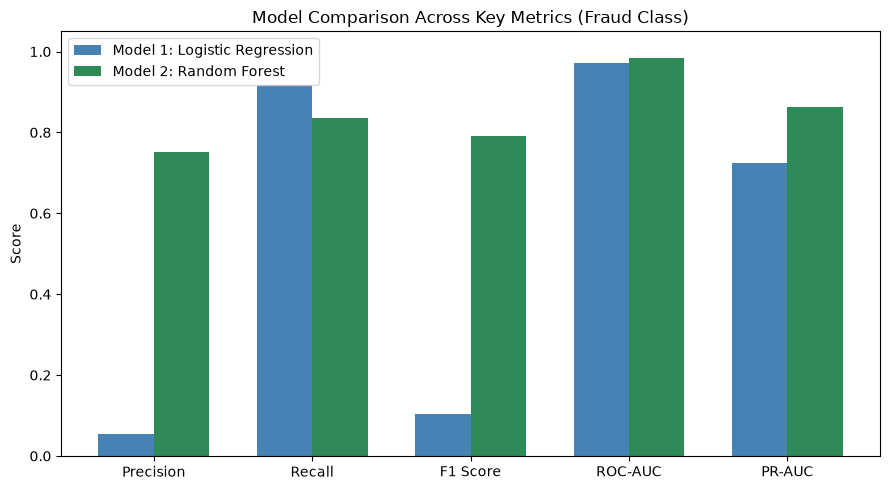

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Compare the two models on the four rate-based metrics (0 to 1 scale)
metrics = ["Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"]
model1_scores = [
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr),
    roc_auc_score(y_test, y_proba_lr),
    average_precision_score(y_test, y_proba_lr),
]
model2_scores = [
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_proba_rf),
    average_precision_score(y_test, y_proba_rf),
]

x = np.arange(len(metrics))  # positions for the groups
width = 0.35                 # width of each bar

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, model1_scores, width, label="Model 1: Logistic Regression", color="steelblue")
ax.bar(x + width/2, model2_scores, width, label="Model 2: Random Forest", color="seagreen")

ax.set_ylabel("Score")
ax.set_title("Model Comparison Across Key Metrics (Fraud Class)")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()